<a href="https://colab.research.google.com/github/zuynali/Pytorch/blob/main/02_neural_network_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sklearn
from sklearn.datasets import make_circles

In [2]:
n_samples=1000
X,y =make_circles(n_samples,noise=0.03,random_state=42)

In [3]:
len(X),len(y)

(1000, 1000)

In [4]:
print(f"{X[:5]}|{y[:5]}")

[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]|[1 1 1 1 0]


In [5]:
import pandas as pd
circles = pd.DataFrame({"X1":X[:,0],"X2":X[:,1],"labels":y})
circles.head(10)

,X1,X2,labels
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


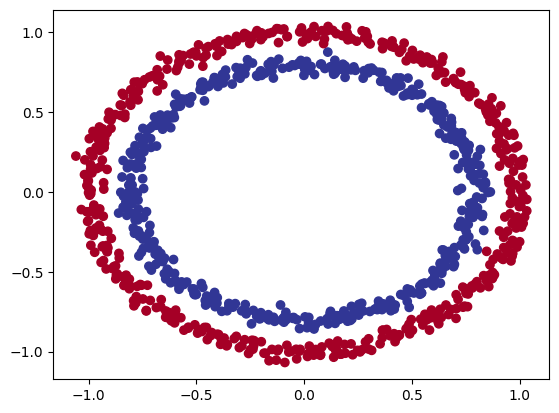

In [6]:
import matplotlib.pyplot as plt
plt.scatter(x=X[:,0],y=X[:,1],c=y,cmap=plt.cm.RdYlBu)

In [7]:
X.shape,y.shape

((1000, 2), (1000,))

In [8]:
X_sample=X[0]
y_sample=y[0]

print(f"values of first sample of X:{X_sample}, and the same for y:{y_sample}")

values of first sample of X:[0.75424625 0.23148074], and the same for y:1


In [9]:
import torch

In [10]:
X = torch.from_numpy(X).type(torch.float)
y= torch.from_numpy(y).type(torch.float)

In [11]:
from numpy import test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [12]:
len(X_train),len(X_test)

(800, 200)

In [13]:
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [14]:
class CircleV0(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1=nn.Linear(in_features=2,out_features=5)
    self.layer_2=nn.Linear(in_features=5,out_features=1)

    def forward(self,x):
      return self.layer_2(self.layer_1(x))


model_0 =CircleV0().to(device)
model_0


CircleV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [15]:
model_0 =nn.Sequential(
    nn.Linear(in_features=2,out_features=5),
    nn.Linear(in_features=5,out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [16]:
with torch.inference_mode():
  untrained_prediction=model_0(X_test.to(device))
untrained_prediction

tensor([[-3.2421e-01],
        [-3.4347e-01],
        [-7.1526e-02],
        [-3.9665e-01],
        [ 2.4944e-01],
        [ 2.3520e-01],
        [-7.3421e-02],
        [ 6.2914e-02],
        [-8.5448e-02],
        [-3.4121e-01],
        [-3.7282e-01],
        [-3.1008e-01],
        [ 2.6523e-03],
        [ 2.8872e-02],
        [-1.2823e-01],
        [ 1.0449e-01],
        [-1.9498e-01],
        [-3.8650e-01],
        [-3.1352e-01],
        [-3.3522e-01],
        [-3.5234e-01],
        [ 1.9070e-01],
        [-2.9550e-01],
        [-3.8383e-01],
        [-1.7138e-01],
        [-9.3933e-03],
        [ 2.0905e-01],
        [ 2.5854e-01],
        [-1.4361e-01],
        [ 7.4755e-02],
        [-9.2540e-02],
        [-1.9891e-01],
        [-3.8221e-01],
        [ 2.1387e-01],
        [-3.9784e-01],
        [-2.7080e-01],
        [-3.4995e-01],
        [ 5.7839e-05],
        [ 1.8711e-01],
        [ 5.2614e-02],
        [-2.9424e-01],
        [-1.4364e-01],
        [-1.8347e-01],
        [ 2

In [17]:
loss_fn= torch.nn.BCEWithLogitsLoss()

opt = torch.optim.SGD(params=model_0.parameters(),lr=0.01)

In [18]:
#calculate accuracy
def accuracy_fn(y_true,y_pred):
  correct=torch.eq(y_true,y_pred).sum().item()
  accuracy=(correct/len(y_pred))*100
  return accuracy

#Training Loop
FCZBO


In [19]:
model_0.eval()
with torch.inference_mode():
  y_logits=model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.3242],
        [-0.3435],
        [-0.0715],
        [-0.3966],
        [ 0.2494]], device='cuda:0')

In [20]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [21]:
y_pred_prob=torch.sigmoid(y_logits)
y_pred_prob

tensor([[0.4196],
        [0.4150],
        [0.4821],
        [0.4021],
        [0.5620]], device='cuda:0')

In [22]:
torch.round(y_pred_prob)


tensor([[0.],
        [0.],
        [0.],
        [0.],
        [1.]], device='cuda:0')

In [23]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs=100

X_train, y_train, X_test, y_test= X_train.to(device), y_train.to(device), X_test.to(device), y_test.to(device)

for epoch in range(epochs):

  model_0.train()

  y_logits=model_0(X_train).squeeze()

  y_pred= torch.round(torch.sigmoid(y_logits))

  loss=loss_fn(y_logits,y_train)

  acc=accuracy_fn(y_true=y_train,y_pred=y_pred)

  opt.zero_grad()

  loss.backward()

  opt.step()

  model_0.eval()

  with torch.inference_mode():
    test_logits=model_0(X_test).squeeze()
    test_pred=torch.round(torch.sigmoid(test_logits))

    test_loss=loss_fn(test_logits,y_test)

    test_acc=accuracy_fn(y_true=y_test,y_pred=test_pred)

  if epoch%10==0:

    print(f"Epoch:{epoch} | Loss:{loss:5f} | Acc: {acc:2f}% | Test loss: {test_loss:5f} | Test Acc: {test_acc:2f}%")



Epoch:0 | Loss:0.701123 | Acc: 48.750000% | Test loss: 0.694898 | Test Acc: 50.500000%
Epoch:10 | Loss:0.700863 | Acc: 49.125000% | Test loss: 0.694706 | Test Acc: 50.500000%
Epoch:20 | Loss:0.700617 | Acc: 49.250000% | Test loss: 0.694528 | Test Acc: 50.000000%
Epoch:30 | Loss:0.700383 | Acc: 49.375000% | Test loss: 0.694363 | Test Acc: 49.500000%
Epoch:40 | Loss:0.700161 | Acc: 49.250000% | Test loss: 0.694209 | Test Acc: 49.500000%
Epoch:50 | Loss:0.699950 | Acc: 49.125000% | Test loss: 0.694066 | Test Acc: 49.500000%
Epoch:60 | Loss:0.699749 | Acc: 49.125000% | Test loss: 0.693932 | Test Acc: 49.500000%
Epoch:70 | Loss:0.699558 | Acc: 49.250000% | Test loss: 0.693807 | Test Acc: 49.000000%
Epoch:80 | Loss:0.699375 | Acc: 49.250000% | Test loss: 0.693691 | Test Acc: 49.000000%
Epoch:90 | Loss:0.699200 | Acc: 49.375000% | Test loss: 0.693582 | Test Acc: 48.500000%


In [24]:
import requests
from pathlib import Path

if Path("helper_function.py").is_file():
  print("helper function exists")
else:
  print("Downloading helper functions")
  request=requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_function.py","wb") as f:
    f.write(request.content)


helper function exists


In [25]:
from helper_function import plot_predictions, plot_decision_boundary

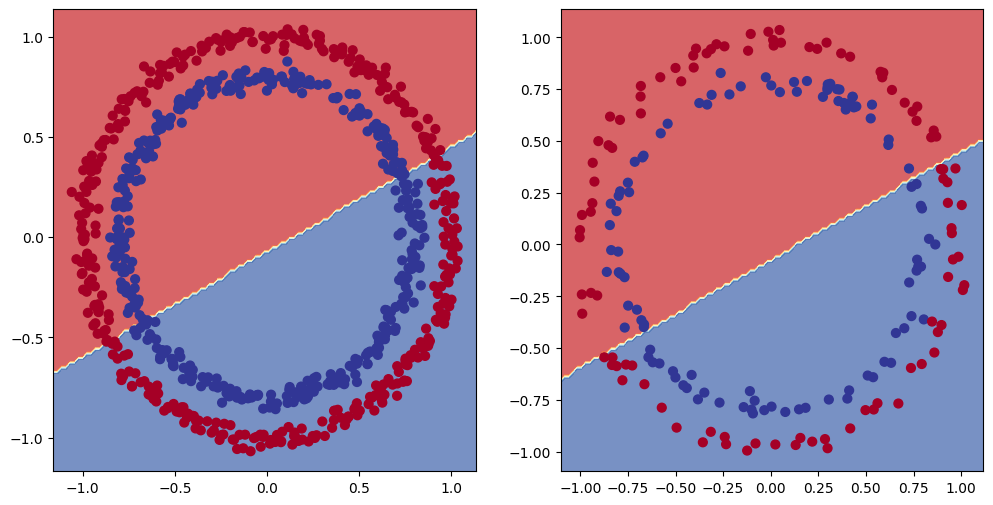

In [26]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plot_decision_boundary(model_0,X_train,y_train)
plt.subplot(1,2,2)
plot_decision_boundary(model_0,X_test,y_test)